Peak Overshoot: 10.85%
Settling Time (2%): 9.12 s


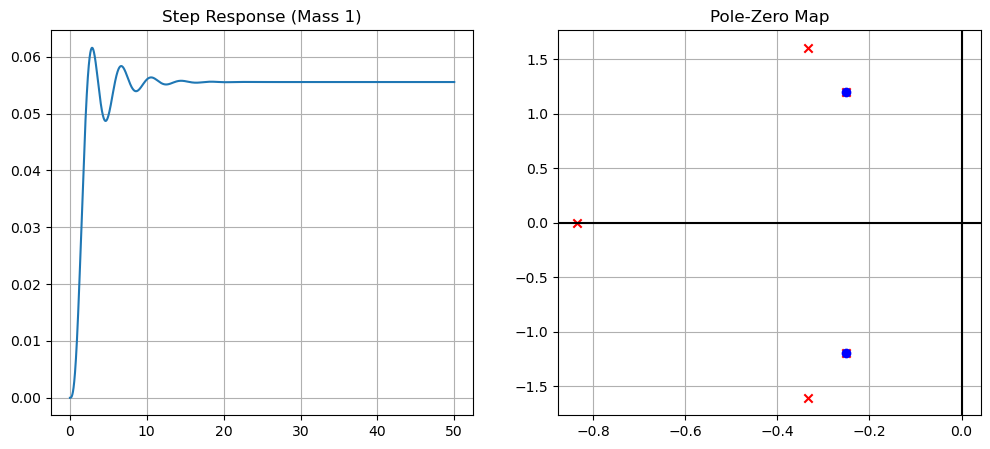

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# System Parameters
M1, M2, M3 = 4, 4, 4
B1, B2, B3 = 2, 2, 2
K1, K2 = 6, 6

# Characteristic Polynomial D(s) Coefficients
d5 = M1*M2*M3
d4 = (B1*M1*M3 + B1*M2*M3 + B2*M1*M3 + B3*M1*M2)
d3 = (B1*B2*M3 + B1*B3*M1 + B1*B3*M2 + B2*B3*M1 + K1*M2*M3 + K2*M1*M2 + K2*M1*M3)
d2 = (B1*B2*B3 + B1*K1*M3 + B1*K2*M1 + B1*K2*M2 + B1*K2*M3 + B2*K1*M3 + B2*K2*M1 + B3*K1*M2 + B3*K2*M1)
d1 = (B1*B2*K2 + B1*B3*K1 + B1*B3*K2 + B2*B3*K1 + K1*K2*M2 + K1*K2*M3)
d0 = (B1*K1*K2 + B2*K1*K2 + B3*K1*K2)
den = [d5, d4, d3, d2, d1, d0]

# Numerator for H1(s)
num = [B1*M3, B1*B3, B1*K2]

# System Definition
sys = signal.TransferFunction(num, den)

# Transient Simulation
t_axis = np.linspace(0, 50, 5000)
t, y = signal.step(sys, T=t_axis)

# Metrics Calculation
y_ss = num[-1] / den[-1] # Steady state value
overshoot = (np.max(y) - y_ss) / y_ss * 100
settling_indices = np.where(np.abs(y - y_ss) > 0.02 * y_ss)[0]
settling_time = t[settling_indices[-1]] if len(settling_indices) > 0 else 0

# Results Output
print(f"Peak Overshoot: {overshoot:.2f}%")
print(f"Settling Time (2%): {settling_time:.2f} s")

# Plotting
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(t, y)
plt.title('Step Response (Mass 1)')
plt.grid(True)
plt.subplot(1, 2, 2)
z, p, k = signal.tf2zpk(num, den)
plt.scatter(np.real(p), np.imag(p), marker='x', color='red', label='Poles')
plt.scatter(np.real(z), np.imag(z), marker='o', color='blue', label='Zeros')
plt.title('Pole-Zero Map')
plt.axhline(0, color='black')
plt.axvline(0, color='black')
plt.grid(True)
plt.show()